In [1]:
#setup and data
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.model import fit_model_until, predict_match

df = pd.read_parquet(Path.cwd().parent / "data" / "matches.parquet")
df = df.sort_values("Date").reset_index(drop=True)

# Hold out the 2024-25 season as the test set
TEST_SEASON = "2425"
test = df[df["Season"] == TEST_SEASON].copy()
train_cutoff = test["Date"].min()

print(f"Train: all matches before {train_cutoff.date()} ({(df['Date'] < train_cutoff).sum()} matches)")
print(f"Test:  2024-25 season ({len(test)} matches)")

Train: all matches before 2024-08-09 (918 matches)
Test:  2024-25 season (306 matches)


In [2]:
#training data only
model = fit_model_until(df, train_cutoff)
print(f"Model fit. Pseudo R²: {1 - model.deviance / model.null_deviance:.3f}")

Model fit. Pseudo R²: 0.192


In [3]:
#generate predictions for every test match
predictions = []
skipped_teams = []

for _, row in test.iterrows():
    try:
        p = predict_match(model, row["HomeTeam"], row["AwayTeam"])
        predictions.append({
            "date":         row["Date"],
            "home_team":    row["HomeTeam"],
            "away_team":    row["AwayTeam"],
            "actual":       row["FTR"],
            "p_home":       p["p_home_win"],
            "p_draw":       p["p_draw"],
            "p_away":       p["p_away_win"],
        })
    except Exception as e:
        # New teams promoted into 2024-25 with no training history
        skipped_teams.append((row["HomeTeam"], row["AwayTeam"]))

preds = pd.DataFrame(predictions)

# Report skips honestly — promoted teams that the model has never seen
unknown_teams = set()
for h, a in skipped_teams:
    unknown_teams |= {h, a}
known_teams = set(test["HomeTeam"]) | set(test["AwayTeam"])
unseen = unknown_teams - (set(df[df["Season"] != "2425"]["HomeTeam"]) 
                          | set(df[df["Season"] != "2425"]["AwayTeam"]))

print(f"Generated {len(preds)} predictions; skipped {len(skipped_teams)} matches.")
print(f"Teams promoted into 2024-25 (not in training data): {sorted(unseen)}")
preds.head()
 

Generated 240 predictions; skipped 66 matches.
Teams promoted into 2024-25 (not in training data): []


,date,home_team,away_team,actual,p_home,p_draw,p_away
0,2024-08-09,Sp Lisbon,Rio Ave,H,0.763338,0.155487,0.080338
1,2024-08-10,Casa Pia,Boavista,A,0.451718,0.267795,0.280469
2,2024-08-10,Porto,Gil Vicente,H,0.767841,0.156937,0.074527
3,2024-08-11,Estoril,Santa Clara,A,0.529687,0.251389,0.218880
4,2024-08-11,Famalicao,Benfica,H,0.132825,0.197536,0.669340


In [4]:
#compute the metrics
def log_loss(probs_for_actual: np.ndarray) -> float:
    """Negative log-likelihood of the actual outcomes. Lower = better."""
    return -np.mean(np.log(np.clip(probs_for_actual, 1e-12, 1)))

def brier_score(prob_vectors: np.ndarray, actuals: np.ndarray) -> float:
    """Multi-class Brier score. Lower = better. Range: [0, 2]."""
    return np.mean(np.sum((prob_vectors - actuals) ** 2, axis=1))

# Get the probability your model assigned to the actual outcome of each match
result_to_col = {"H": "p_home", "D": "p_draw", "A": "p_away"}
preds["p_actual"] = preds.apply(
    lambda r: r[result_to_col[r["actual"]]], axis=1
)

# Build the one-hot truth matrix for Brier
actuals_onehot = pd.get_dummies(preds["actual"])[["H", "D", "A"]].values
prob_matrix = preds[["p_home", "p_draw", "p_away"]].values

# Accuracy: did we pick the right one?
preds["predicted"] = preds[["p_home", "p_draw", "p_away"]].idxmax(axis=1).map(
    {"p_home": "H", "p_draw": "D", "p_away": "A"}
)

print("=== YOUR POISSON MODEL ===")
print(f"Log-loss: {log_loss(preds['p_actual'].values):.4f}")
print(f"Brier:    {brier_score(prob_matrix, actuals_onehot):.4f}")
print(f"Accuracy: {(preds['predicted'] == preds['actual']).mean():.1%}")

=== YOUR POISSON MODEL ===
Log-loss: 0.9550
Brier:    0.5644
Accuracy: 52.1%


In [5]:
#baselines
n = len(preds)

# Baseline 1: uniform 33/33/33
uniform_probs = np.full((n, 3), 1/3)
uniform_p_actual = uniform_probs[np.arange(n), preds["actual"].map({"H": 0, "D": 1, "A": 2}).values]

# Baseline 2: league base rate (computed from training data only)
train_df = df[df["Date"] < train_cutoff]
base_rate = train_df["FTR"].value_counts(normalize=True).reindex(["H", "D", "A"]).values
base_probs = np.tile(base_rate, (n, 1))
base_p_actual = base_probs[np.arange(n), preds["actual"].map({"H": 0, "D": 1, "A": 2}).values]

# Baseline 3: bookmaker closing odds (Pinnacle - sharpest book)
# PSCH, PSCD, PSCA are Pinnacle closing odds for home/draw/away
test_with_odds = test.merge(preds[["date", "home_team", "away_team"]],
                             left_on=["Date", "HomeTeam", "AwayTeam"],
                             right_on=["date", "home_team", "away_team"])
test_with_odds = test_with_odds.dropna(subset=["PSCH", "PSCD", "PSCA"])

# Convert decimal odds to probabilities and remove the bookmaker margin
inv = 1 / test_with_odds[["PSCH", "PSCD", "PSCA"]].values
book_probs = inv / inv.sum(axis=1, keepdims=True)  # normalize to remove vig
book_actuals = test_with_odds["FTR"].map({"H": 0, "D": 1, "A": 2}).values
book_onehot = pd.get_dummies(test_with_odds["FTR"])[["H", "D", "A"]].values
book_p_actual = book_probs[np.arange(len(book_probs)), book_actuals]

print(f"=== BASELINE 1: Uniform (33/33/33) ===")
print(f"Log-loss: {log_loss(uniform_p_actual):.4f}")

print(f"\n=== BASELINE 2: League base rate (from training data) ===")
print(f"Log-loss: {log_loss(base_p_actual):.4f}")
print(f"Brier:    {brier_score(base_probs, actuals_onehot):.4f}")

print(f"\n=== BASELINE 3: Pinnacle closing odds ===")
print(f"  (computed on {len(book_probs)} matches with odds data)")
print(f"Log-loss: {log_loss(book_p_actual):.4f}")
print(f"Brier:    {brier_score(book_probs, book_onehot):.4f}")


=== BASELINE 1: Uniform (33/33/33) ===
Log-loss: 1.0986

=== BASELINE 2: League base rate (from training data) ===
Log-loss: 1.0762
Brier:    0.6514

=== BASELINE 3: Pinnacle closing odds ===
  (computed on 240 matches with odds data)
Log-loss: 0.9160
Brier:    0.5415


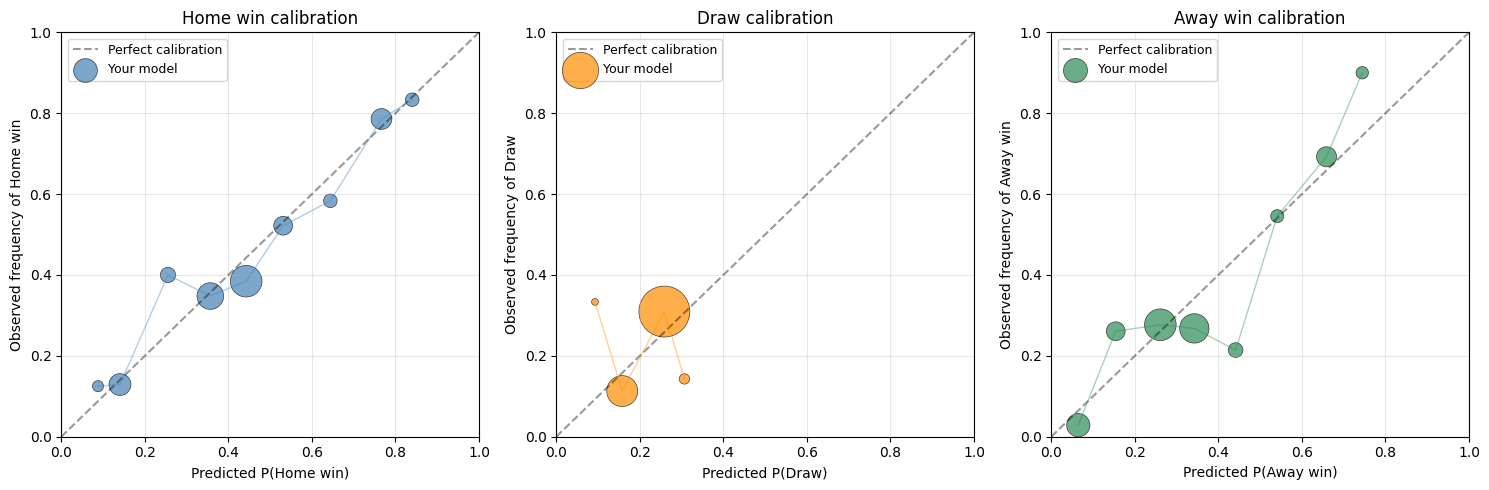

In [6]:
def calibration_data(probs: np.ndarray, actuals: np.ndarray, n_bins: int = 10):
    """For a single class, return (bin_centers, fraction_actual, count_per_bin)."""
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.clip(np.digitize(probs, bins) - 1, 0, n_bins - 1)
    
    centers, fractions, counts = [], [], []
    for i in range(n_bins):
        mask = bin_indices == i
        if mask.sum() < 3:  # skip bins with too few matches
            continue
        centers.append(probs[mask].mean())
        fractions.append(actuals[mask].mean())
        counts.append(mask.sum())
    
    return np.array(centers), np.array(fractions), np.array(counts)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

outcomes = [
    ("p_home", "H", "Home win", "steelblue"),
    ("p_draw", "D", "Draw",     "darkorange"),
    ("p_away", "A", "Away win", "seagreen"),
]

for ax, (prob_col, outcome_code, label, color) in zip(axes, outcomes):
    probs = preds[prob_col].values
    actuals = (preds["actual"] == outcome_code).astype(int).values
    
    centers, fractions, counts = calibration_data(probs, actuals, n_bins=10)
    
    # Diagonal = perfect calibration
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect calibration")
    
    # Your model — point size = number of predictions in that bin
    ax.scatter(centers, fractions, s=counts * 8, color=color,
               alpha=0.7, edgecolor="black", linewidth=0.5, label="Your model")
    ax.plot(centers, fractions, color=color, alpha=0.4, linewidth=1)
    
    ax.set_xlabel(f"Predicted P({label})")
    ax.set_ylabel(f"Observed frequency of {label}")
    ax.set_title(f"{label} calibration")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
fig.savefig(Path.cwd().parent / "data" / "calibration_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
from src.dixon_coles import fit_dixon_coles

dc_model = fit_dixon_coles(df, xi=0.0, cutoff_date=train_cutoff)

# Generate predictions for the test set
dc_predictions = []
dc_skipped = 0

for _, row in test.iterrows():
    try:
        p = dc_model.predict_match(row["HomeTeam"], row["AwayTeam"])
        dc_predictions.append({
            "date":      row["Date"],
            "home_team": row["HomeTeam"],
            "away_team": row["AwayTeam"],
            "actual":    row["FTR"],
            "p_home":    p["p_home_win"],
            "p_draw":    p["p_draw"],
            "p_away":    p["p_away_win"],
        })
    except (ValueError, KeyError):
        dc_skipped += 1

dc_preds = pd.DataFrame(dc_predictions)

# Compute metrics
result_to_col = {"H": "p_home", "D": "p_draw", "A": "p_away"}
dc_preds["p_actual"] = dc_preds.apply(lambda r: r[result_to_col[r["actual"]]], axis=1)
dc_actuals_onehot = pd.get_dummies(dc_preds["actual"])[["H", "D", "A"]].values
dc_prob_matrix = dc_preds[["p_home", "p_draw", "p_away"]].values
dc_preds["predicted"] = dc_preds[["p_home", "p_draw", "p_away"]].idxmax(axis=1).map(
    {"p_home": "H", "p_draw": "D", "p_away": "A"})

print("=== DIXON-COLES (τ correction, no time decay) ===")
print(f"Log-loss: {log_loss(dc_preds['p_actual'].values):.4f}")
print(f"Brier:    {brier_score(dc_prob_matrix, dc_actuals_onehot):.4f}")
print(f"Accuracy: {(dc_preds['predicted'] == dc_preds['actual']).mean():.1%}")
print(f"\nFor comparison:")
print(f"  Maher Poisson:    log-loss 0.9550, Brier 0.5644, Accuracy 52.1%")
print(f"  Pinnacle closing: log-loss 0.9160, Brier 0.5415")

Fitting Dixon-Coles on 918 matches, 23 teams, xi=0.0...
  Done. Final negative log-likelihood: 2546.99
=== DIXON-COLES (τ correction, no time decay) ===
Log-loss: 0.9566
Brier:    0.5657
Accuracy: 52.1%

For comparison:
  Maher Poisson:    log-loss 0.9550, Brier 0.5644, Accuracy 52.1%
  Pinnacle closing: log-loss 0.9160, Brier 0.5415


In [8]:
xi_values = [0.0, 0.0005, 0.001, 0.0015, 0.002, 0.003, 0.005, 0.007]
results = []

for xi in xi_values:
    print(f"\n--- Fitting with xi = {xi} ---")
    dc_model = fit_dixon_coles(df, xi=xi, cutoff_date=train_cutoff)
    
    # Generate predictions on the test set
    rows = []
    skipped = 0
    for _, row in test.iterrows():
        try:
            p = dc_model.predict_match(row["HomeTeam"], row["AwayTeam"])
            rows.append({
                "actual": row["FTR"],
                "p_home": p["p_home_win"],
                "p_draw": p["p_draw"],
                "p_away": p["p_away_win"],
            })
        except (ValueError, KeyError):
            skipped += 1
    
    p_df = pd.DataFrame(rows)
    p_df["p_actual"] = p_df.apply(
        lambda r: r[{"H": "p_home", "D": "p_draw", "A": "p_away"}[r["actual"]]],
        axis=1,
    )
    p_df["predicted"] = p_df[["p_home", "p_draw", "p_away"]].idxmax(axis=1).map(
        {"p_home": "H", "p_draw": "D", "p_away": "A"}
    )
    
    ll = log_loss(p_df["p_actual"].values)
    acc = (p_df["predicted"] == p_df["actual"]).mean()
    half_life_years = (np.log(2) / xi / 365) if xi > 0 else float("inf")
    
    results.append({
        "xi": xi,
        "half_life_years": half_life_years,
        "rho": dc_model.rho,
        "log_loss": ll,
        "accuracy": acc,
        "n_test": len(p_df),
    })
    print(f"  xi={xi}, half-life={half_life_years:.2f}y, rho={dc_model.rho:.4f}, "
          f"log-loss={ll:.4f}, accuracy={acc:.1%}")

results_df = pd.DataFrame(results)
print("\n=== Summary ===")
print(results_df.to_string(index=False))


--- Fitting with xi = 0.0 ---
Fitting Dixon-Coles on 918 matches, 23 teams, xi=0.0...
  Done. Final negative log-likelihood: 2546.99
  xi=0.0, half-life=infy, rho=0.0540, log-loss=0.9566, accuracy=52.1%

--- Fitting with xi = 0.0005 ---
Fitting Dixon-Coles on 918 matches, 23 teams, xi=0.0005...
  Done. Final negative log-likelihood: 2016.36
  xi=0.0005, half-life=3.80y, rho=0.0607, log-loss=0.9567, accuracy=51.7%

--- Fitting with xi = 0.001 ---
Fitting Dixon-Coles on 918 matches, 23 teams, xi=0.001...
  Done. Final negative log-likelihood: 1634.46
  xi=0.001, half-life=1.90y, rho=0.0647, log-loss=0.9570, accuracy=52.5%

--- Fitting with xi = 0.0015 ---
Fitting Dixon-Coles on 918 matches, 23 teams, xi=0.0015...
  Done. Final negative log-likelihood: 1354.96
  xi=0.0015, half-life=1.27y, rho=0.0660, log-loss=0.9574, accuracy=52.9%

--- Fitting with xi = 0.002 ---
Fitting Dixon-Coles on 918 matches, 23 teams, xi=0.002...
  Done. Final negative log-likelihood: 1146.76
  xi=0.002, half-li